## TUGAS PEMROGRAMAN PARALEL 3

#### Nama           : Naila Faiza Inshyra
#### NIM            : 2411512013
#### Kelas          : Pemorograman Paralel A
#### Jurusan        : Teknik Komputer
#### Dosen Pengampu : Ibu Desta Yolanda

### Tahap Awal: Fungsi Worker (ditulis ke `tugas3_helpers.py`)

In [13]:
%%writefile tugas3_helpers.py
import random

# ---------- Soal 1: fungsi dari Pertemuan 1 / eksperimen 7.1 ----------
def hitung_prima(n):
    primes = []
    for num in range(2, n):
        is_prime = True
        for i in range(2, int(num ** 0.5) + 1):
            if num % i == 0:
                is_prime = False
                break
        if is_prime:
            primes.append(num)
    return len(primes)

# ---------- Soal 2: menjumlahkan angka acak ----------
def subtotal_acak(seed, jumlah):
    """Jumlahkan `jumlah` angka acak 1..100 (seed tetap agar hasil bisa diverifikasi)."""
    rng = random.Random(seed)
    total = 0
    for _ in range(jumlah):
        total += rng.randint(1, 100)
    return total

def worker_queue(seed, jumlah, q):
    # (a) Message passing: hitung subtotal lokal, kirim SATU pesan lewat Queue
    q.put(subtotal_acak(seed, jumlah))

def worker_value_per_angka(seed, jumlah, shared_val, lock):
    # (b) Shared memory: setiap angka langsung ditambahkan ke Value (dilindungi Lock)
    rng = random.Random(seed)
    for _ in range(jumlah):
        x = rng.randint(1, 100)
        with lock:
            shared_val.value += x

def worker_value_batch(seed, jumlah, shared_val, lock):
    # (b') Varian shared memory yang dioptimasi: subtotal lokal, lock hanya 1x
    subtotal = subtotal_acak(seed, jumlah)
    with lock:
        shared_val.value += subtotal

# ---------- Soal 3: producer-consumer ----------
def producer(q, jumlah_item, n_consumer, nilai_n):
    for _ in range(jumlah_item):
        q.put(nilai_n)              # 1 item = 1 tugas CPU-bound
    for _ in range(n_consumer):
        q.put(None)                 # sentinel: 1 per consumer

def consumer(q, hasil_q):
    while True:
        item = q.get()
        if item is None:
            break
        hasil_q.put(hitung_prima(item))

# ---------- Soal 4: benchmark counter ----------
def worker_counter(jumlah, counter, lock):
    for _ in range(jumlah):
        with lock:
            counter.value += 1

Overwriting tugas3_helpers.py


In [14]:
import os, time, statistics, queue, threading
import multiprocessing as mp
import matplotlib.pyplot as plt

import tugas3_helpers as h

# Soal meminta: mp.get_context('fork').Pool(...). 'fork' tidak tersedia di Windows,
# jadi otomatis pakai 'spawn' di sana (hasil tetap benar, hanya overhead start lebih besar).
METHOD = 'fork' if 'fork' in mp.get_all_start_methods() else 'spawn'
ctx = mp.get_context(METHOD)

JUMLAH_CORE = os.cpu_count() or 1
print(f"Sistem operasi/start method : {METHOD}")
print(f"Jumlah CPU logis terdeteksi : {JUMLAH_CORE}")

Sistem operasi/start method : spawn
Jumlah CPU logis terdeteksi : 12


### SOAL NOMOR 1

Soal Nomor 1:
Analisis Speedup Skala: Ulangi eksperimen 7.1 (hitung_prima ) dengan jumlah worker = 1, 2, 4, 8 (gunakan
mp.get_context('fork').Pool(processes=...) agar konsisten). Plot speedup vs jumlah worker, lalu bandingkan dengan kurva Hukum
Amdahl dari Pertemuan 1. Jelaskan mengapa kurva aktual mungkin tidak persis mengikuti kurva teoritis (pertimbangkan: jumlah core fisik mesin
kalian, overhead pembuatan proses, dan beban kerja lain yang mungkin berjalan bersamaan).

**Rancangan eksperimen**

- Fungsi: `hitung_prima(n)` (sama dengan eksperimen 7.1).
- Beban: **8 tugas independen**, masing-masing mencari jumlah prima di bawah 200.000. Saya memakai 8 tugas (bukan 4 seperti di 7.1) supaya konfigurasi 8 worker benar-benar punya pekerjaan; dengan hanya 4 tugas, worker ke-5 s.d. ke-8 pasti menganggur sehingga kurva otomatis mendatar di angka 4.
- Baseline: eksekusi **sekuensial** (satu proses, tanpa Pool).
- Paralel: `ctx.Pool(processes=w).map(...)`, `w ∈ {1, 2, 4, 8}`, waktu termasuk pembuatan Pool (seperti di 7.1). Tiap konfigurasi diulang 3 kali, diambil **median**.
- Speedup: $S(w) = T_{\text{sekuensial}} / T_{\text{paralel}}(w)$.
- Pembanding teoritis: Hukum Amdahl $S(N) = \dfrac{1}{(1-P) + P/N}$.

In [3]:
DAFTAR_N = [200_000] * 8
WORKERS  = [1, 2, 4, 8]
ULANG    = 3

def median_waktu(fungsi, ulang=ULANG):
    hasil = []
    for _ in range(ulang):
        t0 = time.perf_counter()
        out = fungsi()
        hasil.append(time.perf_counter() - t0)
    return statistics.median(hasil), out

# --- Baseline sekuensial ---
t_seq, hasil_seq = median_waktu(lambda: [h.hitung_prima(n) for n in DAFTAR_N])
print(f"[Sekuensial]  hasil: {hasil_seq}  waktu: {t_seq:.3f} detik\n")

# --- Paralel dengan berbagai jumlah worker ---
def jalankan_pool(w):
    with ctx.Pool(processes=w) as pool:
        return pool.map(h.hitung_prima, DAFTAR_N)

waktu_par, speedup = {}, {}
for w in WORKERS:
    t, hasil = median_waktu(lambda: jalankan_pool(w))
    assert hasil == hasil_seq, "Hasil paralel tidak sama dengan sekuensial!"
    waktu_par[w] = t
    speedup[w] = t_seq / t
    print(f"[Pool w={w}]  waktu: {t:.3f} detik   speedup: {speedup[w]:.2f}x   efisiensi: {speedup[w]/w*100:.0f}%")

# --- Ukur overhead pembuatan Pool saja (tanpa kerja) ---
print("\nOverhead pembuatan + penutupan Pool (tanpa pekerjaan):")
overhead = {}
for w in WORKERS:
    t, _ = median_waktu(lambda: ctx.Pool(processes=w).close() or None)
    overhead[w] = t
    print(f"  w={w}: {t*1000:.1f} ms")

[Sekuensial]  hasil: [17984, 17984, 17984, 17984, 17984, 17984, 17984, 17984]  waktu: 2.133 detik

[Pool w=1]  waktu: 2.240 detik   speedup: 0.95x   efisiensi: 95%
[Pool w=2]  waktu: 1.229 detik   speedup: 1.74x   efisiensi: 87%
[Pool w=4]  waktu: 0.727 detik   speedup: 2.93x   efisiensi: 73%
[Pool w=8]  waktu: 0.630 detik   speedup: 3.38x   efisiensi: 42%

Overhead pembuatan + penutupan Pool (tanpa pekerjaan):
  w=1: 9.1 ms
  w=2: 9.5 ms
  w=4: 19.3 ms
  w=8: 55.5 ms


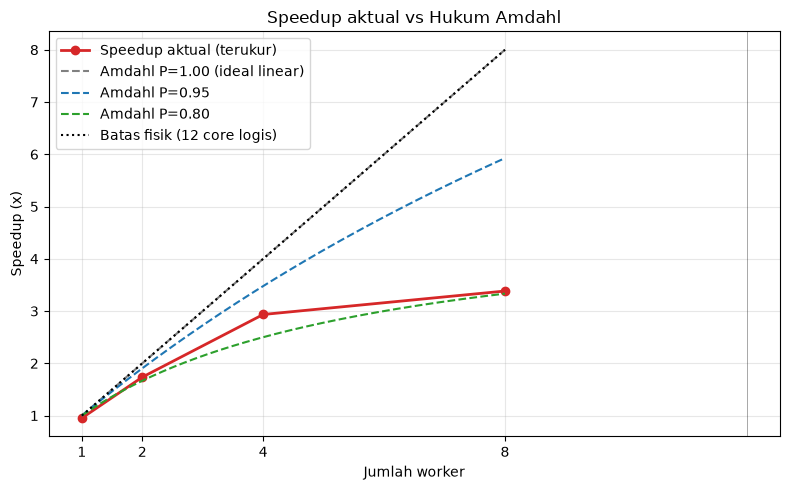

In [4]:
# --- Plot speedup aktual vs kurva Amdahl ---
import numpy as np
N = np.linspace(1, max(WORKERS), 200)
amdahl = lambda P, n: 1 / ((1 - P) + P / n)

plt.figure(figsize=(8, 5))
plt.plot(WORKERS, [speedup[w] for w in WORKERS], 'o-', lw=2, color='tab:red', label='Speedup aktual (terukur)')
plt.plot(N, amdahl(1.0, N),  '--', color='gray',  label='Amdahl P=1.00 (ideal linear)')
plt.plot(N, amdahl(0.95, N), '--', color='tab:blue',  label='Amdahl P=0.95')
plt.plot(N, amdahl(0.80, N), '--', color='tab:green', label='Amdahl P=0.80')
plt.plot(N, np.minimum(N, JUMLAH_CORE), ':', color='black', label=f'Batas fisik ({JUMLAH_CORE} core logis)')
plt.axvline(JUMLAH_CORE, color='black', lw=0.6, alpha=0.4)
plt.xlabel('Jumlah worker'); plt.ylabel('Speedup (x)')
plt.title('Speedup aktual vs Hukum Amdahl'); plt.xticks(WORKERS)
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

In [5]:
# --- Ringkasan otomatis (menyesuaikan hasil di mesin kamu) ---
print(f"Core logis mesin ini: {JUMLAH_CORE}\n")
print(f"{'worker':>6} | {'aktual':>7} | {'Amdahl P=1':>10} | {'Amdahl P=.95':>12} | {'efisiensi (S/w)':>15}")
for w in WORKERS:
    print(f"{w:>6} | {speedup[w]:>6.2f}x | {amdahl(1.0,w):>9.2f}x | {amdahl(0.95,w):>11.2f}x | {speedup[w]/w*100:>14.0f}%")

best_w = max(WORKERS, key=lambda w: speedup[w])
print(f"\nSpeedup tertinggi: {speedup[best_w]:.2f}x pada w={best_w}")
if speedup[8] <= speedup[4] * 1.05:
    print("-> Dari 4 ke 8 worker speedup hampir tidak naik / turun: sudah menyentuh batas core fisik + overhead.")
if JUMLAH_CORE < max(WORKERS):
    print(f"-> Worker maksimum ({max(WORKERS)}) > core logis ({JUMLAH_CORE}): sebagian proses harus bergantian memakai core.")

# Estimasi fraksi paralel efektif P dari titik w=4:  S = 1/((1-P)+P/N)  ->  P = (1/S - 1)/(1/N - 1)
S4 = speedup[4]
P_eff = max(0.0, min(1.0, (1/S4 - 1) / (1/4 - 1)))
print(f"Estimasi P efektif dari titik w=4: {P_eff:.2f} (P=1 artinya seluruh kerja bisa diparalelkan tanpa biaya)")

Core logis mesin ini: 12

worker |  aktual | Amdahl P=1 | Amdahl P=.95 | efisiensi (S/w)
     1 |   0.95x |      1.00x |        1.00x |             95%
     2 |   1.74x |      2.00x |        1.90x |             87%
     4 |   2.93x |      4.00x |        3.48x |             73%
     8 |   3.38x |      8.00x |        5.93x |             42%

Speedup tertinggi: 3.38x pada w=8
Estimasi P efektif dari titik w=4: 0.88 (P=1 artinya seluruh kerja bisa diparalelkan tanpa biaya)


### Penjelasan Soal 1

**Mengapa kurva aktual bisa tidak mengikuti kurva Amdahl?** Kurva Amdahl hanya memodelkan satu hal: bagian program yang serial ($1-P$) membatasi percepatan. Model itu *mengasumsikan* $N$ unit pemroses benar-benar tersedia dan overhead paralelisasi nol. Pada praktiknya:

1. **Jumlah core fisik terbatas.** Speedup tidak bisa melewati jumlah core yang benar-benar bisa berjalan bersamaan. Jika `worker > core`, proses-proses tambahan hanya bergantian memakai core yang sama (*context switch*), sehingga kurva mendatar (atau turun) setelah titik jumlah core. Kurva Amdahl tetap naik karena tidak mengenal batas ini.
2. **Hyper-threading ≠ core penuh.** `os.cpu_count()` menghitung *logical CPU*. Dua thread hardware pada satu core fisik berbagi ALU/cache, jadi pekerjaan CPU-bound biasanya hanya ~1,2–1,3× lebih cepat, bukan 2×.
3. **Overhead pembuatan proses.** Tiap worker adalah proses OS baru (`fork`/`spawn`, inisialisasi interpreter, pengaturan pipe). Dari hasil sel di atas terlihat biayanya milidetik hingga puluhan milidetik dan **bertambah seiring jumlah worker**. Jika total kerja kecil, overhead ini memakan porsi besar dari waktu total.
4. **Overhead komunikasi (IPC).** `Pool.map` mem-*pickle* argumen dan hasil lalu mengirimnya lewat pipe. Biaya ini tidak ada di program sekuensial dan tidak ada di rumus Amdahl.
5. **Beban kerja tidak seimbang / granularitas kasar.** Jumlah tugas hanya 8. Dengan 8 tugas dan 4 worker, kerja terbagi rata (2 tugas per worker); tetapi bila jumlah tugas tidak habis dibagi jumlah worker, sebagian worker menganggur di akhir (*load imbalance*). Pada eksperimen 7.1 (4 tugas), lebih dari 4 worker sama sekali tidak berguna.
6. **Faktor sistem lain:** persaingan *memory bandwidth* dan cache, proses lain di OS, serta *turbo boost* CPU yang menurunkan frekuensi saat banyak core aktif.

**Kesimpulan:** Amdahl memberi *batas atas teoretis*; speedup nyata = batas Amdahl **dikurangi** efek batas core fisik dan seluruh overhead di atas. Semakin besar beban kerja per tugas dan semakin sedikit komunikasi, semakin dekat kurva aktual ke kurva teoretis. Lihat tabel di sel ringkasan untuk angka spesifik di mesin ini.

### SOAL NOMOR 2

Soal Nomor 2:
Shared Memory vs Message Passing: Buat dua versi program yang menghitung total dari 4 proses yang masing-masing menjumlahkan 1 juta angka
acak: (a) versi menggunakan Queue (message passing, setiap proses kirim subtotal lewat queue, main process menjumlahkan), dan (b) versi
menggunakan Value (shared memory dengan Lock, setiap proses langsung menambah ke shared value). Ukur dan bandingkan waktu eksekusi
keduanya.

**Tugas:** 4 proses, masing-masing menjumlahkan 1 juta angka acak (1–100). Total akhir = jumlah 4 subtotal.

- **(a) Queue (message passing):** tiap proses menghitung subtotalnya secara lokal lalu mengirim **1 pesan** ke `Queue`; proses utama menjumlahkan.
- **(b) Value + Lock (shared memory):** tiap proses langsung menambahkan **setiap angka** ke `Value` bersama, dengan `Lock` untuk mencegah *race condition*. Ini interpretasi paling harfiah dari soal ("langsung menambah ke shared value").
- **(b′) Tambahan:** varian Value yang dioptimasi (subtotal lokal, lock hanya sekali) sebagai pembanding yang adil, agar terlihat bahwa perbedaan ditentukan oleh **pola pemakaian**, bukan semata oleh mekanismenya.

Seed setiap proses tetap (0..3) sehingga total yang benar bisa dihitung ulang dan diverifikasi.

In [6]:
NPROC  = 4
JUMLAH = 1_000_000

# Nilai yang benar (juga menjadi baseline sekuensial)
t0 = time.perf_counter()
TOTAL_BENAR = sum(h.subtotal_acak(i, JUMLAH) for i in range(NPROC))
T_SEQ2 = time.perf_counter() - t0
print(f"Total yang benar (sekuensial): {TOTAL_BENAR:,}   waktu: {T_SEQ2:.3f} detik\n")

def versi_queue():
    q = ctx.Queue()
    ps = [ctx.Process(target=h.worker_queue, args=(i, JUMLAH, q)) for i in range(NPROC)]
    t0 = time.perf_counter()
    for p in ps: p.start()
    total = sum(q.get() for _ in range(NPROC))   # ambil hasil SEBELUM join (hindari deadlock)
    for p in ps: p.join()
    return total, time.perf_counter() - t0

def versi_value(worker):
    v = ctx.Value('q', 0, lock=False)            # 'q' = signed long long
    lock = ctx.Lock()
    ps = [ctx.Process(target=worker, args=(i, JUMLAH, v, lock)) for i in range(NPROC)]
    t0 = time.perf_counter()
    for p in ps: p.start()
    for p in ps: p.join()
    return v.value, time.perf_counter() - t0

hasil2 = {}
for nama, fn in [("(a) Queue",                    versi_queue),
                 ("(b) Value+Lock per angka",     lambda: versi_value(h.worker_value_per_angka)),
                 ("(b') Value+Lock subtotal",     lambda: versi_value(h.worker_value_batch))]:
    total, waktu = fn()
    hasil2[nama] = waktu
    status = "BENAR" if total == TOTAL_BENAR else "SALAH!"
    print(f"{nama:<26} total = {total:,}  [{status}]  waktu: {waktu:.3f} detik")

Total yang benar (sekuensial): 202,026,957   waktu: 0.819 detik

(a) Queue                  total = 202,026,957  [BENAR]  waktu: 0.373 detik
(b) Value+Lock per angka   total = 202,026,957  [BENAR]  waktu: 22.346 detik
(b') Value+Lock subtotal   total = 202,026,957  [BENAR]  waktu: 0.382 detik


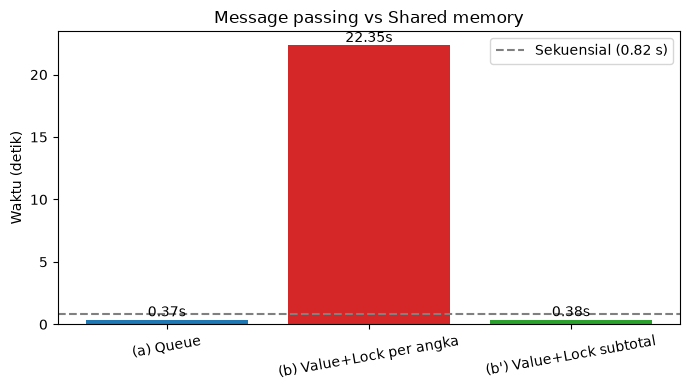

Value+Lock per angka 59.8x lebih lambat daripada Queue.
Value+Lock subtotal  1.02x waktu Queue (hampir sama, karena sama-sama hanya 1 komunikasi per proses).


In [7]:
# Grafik perbandingan waktu
plt.figure(figsize=(7, 4))
bars = plt.bar(list(hasil2.keys()), list(hasil2.values()), color=['tab:blue', 'tab:red', 'tab:green'])
plt.axhline(T_SEQ2, color='gray', ls='--', label=f'Sekuensial ({T_SEQ2:.2f} s)')
for b, v in zip(bars, hasil2.values()):
    plt.text(b.get_x() + b.get_width()/2, v, f"{v:.2f}s", ha='center', va='bottom')
plt.ylabel('Waktu (detik)'); plt.title('Message passing vs Shared memory'); plt.legend()
plt.xticks(rotation=10); plt.tight_layout(); plt.show()

a, b, b2 = hasil2["(a) Queue"], hasil2["(b) Value+Lock per angka"], hasil2["(b') Value+Lock subtotal"]
print(f"Value+Lock per angka {b/a:.1f}x lebih lambat daripada Queue.")
print(f"Value+Lock subtotal  {b2/a:.2f}x waktu Queue (hampir sama, karena sama-sama hanya 1 komunikasi per proses).")

### Penjelasan Soal 2

**Hasil kedua versi identik dan sama dengan nilai yang benar**, sehingga perbedaannya murni pada performa.

- **(a) Queue:** setiap proses bekerja penuh secara lokal (tanpa saling menunggu) dan hanya melakukan **1 operasi komunikasi** (`put` satu integer ≈ mikrodetik). Total komunikasi: 4 pesan.
- **(b) Value + Lock per angka:** ada **4.000.000 kali** akses ke variabel bersama, dan setiap akses harus memperoleh `Lock` antar-proses (semaphore tingkat OS, lebih mahal daripada `threading.Lock`). Karena kritis-seksi yang sama dipakai keempat proses, mereka **saling menunggu (lock contention)**, sehingga paralelisme praktis hilang dan biaya *acquire/release* mendominasi waktu. Hasilnya lebih lambat (lihat rasio pada output; pada mesin multi-core selisihnya biasanya jauh lebih besar karena contention meningkat, sedangkan pada mesin 1–2 core selisihnya lebih kecil).
- **(b′) Value + Lock subtotal:** dengan menjumlahkan lokal dulu lalu meng-*update* sekali, waktu turun ke level yang sama dengan Queue. Jadi masalahnya bukan pada shared memory itu sendiri, melainkan pada **frekuensi sinkronisasi**.

**Pelajaran:** untuk komputasi kecil-kecilan yang menghasilkan hasil ringkas (reduksi), *message passing* lebih sederhana dan lebih aman (tanpa lock, tanpa race condition). Shared memory unggul bila datanya besar dan harus dibaca/tulis banyak proses tanpa disalin, **dengan syarat** akses ke bagian yang dilindungi lock dibuat sesedikit mungkin.

### SOAL NOMOR 3

Soal Nomor 3:
Producer-Consumer Antar-Proses: Modifikasi contoh producer-consumer queue.Queue dari Pertemuan 2 (yang berbasis thread) menjadi
berbasis multiprocessing.Queue dan multiprocessing.Process. Apakah pola kode secara struktur banyak berubah? Apa perbedaan
performa yang kalian amati untuk tugas yang CPU-bound (bukan I/O-bound seperti pada versi Pertemuan 2)?

Pola dari Pertemuan 2: satu *producer* mengisi antrean, beberapa *consumer* mengambil dan memproses item, penutupan memakai *sentinel* `None` (satu per consumer). Di sini beban tiap item adalah **CPU-bound** (`hitung_prima`), bukan I/O-bound (`sleep`) seperti di Pertemuan 2.

Fungsi `producer` dan `consumer` (di `tugas3_helpers.py`) **ditulis sekali** dan dipakai oleh dua versi:

| | Versi thread (Pertemuan 2) | Versi proses (Pertemuan 6) |
|---|---|---|
| Antrean | `queue.Queue` | `multiprocessing.Queue` |
| Eksekutor | `threading.Thread` | `multiprocessing.Process` |

Setup: 16 item (masing-masing `hitung_prima(100_000)`), 4 consumer. Hasil consumer dikirim balik lewat antrean hasil kedua.

In [8]:
JUMLAH_ITEM, N_CONSUMER, NILAI_N = 16, 4, 100_000

def pipeline(Worker, QueueCls, n_consumer=N_CONSUMER):
    q, hasil_q = QueueCls(), QueueCls()
    prod = Worker(target=h.producer, args=(q, JUMLAH_ITEM, n_consumer, NILAI_N))
    cons = [Worker(target=h.consumer, args=(q, hasil_q)) for _ in range(n_consumer)]
    t0 = time.perf_counter()
    prod.start()
    for c in cons: c.start()
    hasil = [hasil_q.get() for _ in range(JUMLAH_ITEM)]   # kumpulkan hasil SEBELUM join
    prod.join()
    for c in cons: c.join()
    return hasil, time.perf_counter() - t0

# Baseline: sekuensial, satu proses
t0 = time.perf_counter()
hasil_seq3 = [h.hitung_prima(NILAI_N) for _ in range(JUMLAH_ITEM)]
t_seq3 = time.perf_counter() - t0

hasil_thr,  t_thr  = pipeline(threading.Thread, queue.Queue)
hasil_proc, t_proc = pipeline(ctx.Process,      ctx.Queue)

assert hasil_thr == hasil_proc == hasil_seq3, "Hasil berbeda!"
print(f"Semua versi menghasilkan hasil sama: {hasil_seq3[:3]}... ({JUMLAH_ITEM} item)\n")
print(f"Sekuensial                 : {t_seq3:.3f} detik")
print(f"Thread  + queue.Queue      : {t_thr:.3f} detik   (speedup {t_seq3/t_thr:.2f}x)")
print(f"Process + mp.Queue         : {t_proc:.3f} detik   (speedup {t_seq3/t_proc:.2f}x)")
print(f"\nJumlah core logis: {JUMLAH_CORE}")

Semua versi menghasilkan hasil sama: [9592, 9592, 9592]... (16 item)

Sekuensial                 : 1.682 detik
Thread  + queue.Queue      : 1.724 detik   (speedup 0.98x)
Process + mp.Queue         : 0.626 detik   (speedup 2.69x)

Jumlah core logis: 12


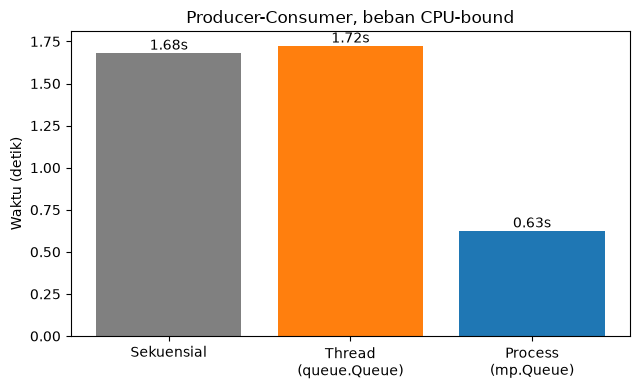

Thread tidak lebih cepat dari sekuensial -> GIL mencegah eksekusi bytecode Python paralel.
Process lebih cepat dari Thread -> proses punya interpreter & GIL sendiri (true parallelism).


In [9]:
plt.figure(figsize=(6.5, 4))
labels = ['Sekuensial', 'Thread\n(queue.Queue)', 'Process\n(mp.Queue)']
vals = [t_seq3, t_thr, t_proc]
bars = plt.bar(labels, vals, color=['gray', 'tab:orange', 'tab:blue'])
for b, v in zip(bars, vals):
    plt.text(b.get_x() + b.get_width()/2, v, f"{v:.2f}s", ha='center', va='bottom')
plt.ylabel('Waktu (detik)'); plt.title('Producer-Consumer, beban CPU-bound')
plt.tight_layout(); plt.show()

if t_thr > 0.85 * t_seq3:
    print("Thread tidak lebih cepat dari sekuensial -> GIL mencegah eksekusi bytecode Python paralel.")
if t_proc < 0.85 * t_thr:
    print("Process lebih cepat dari Thread -> proses punya interpreter & GIL sendiri (true parallelism).")
elif JUMLAH_CORE <= 2:
    print("Mesin ini hanya punya sedikit core, sehingga keunggulan proses tidak tampak jelas; correctness tetap benar.")

### Penjelasan Soal 3

**Apakah struktur kode banyak berubah? — Tidak, bagian intinya nyaris sama.** Fungsi `producer` dan `consumer` **tidak diubah sama sekali**; keduanya hanya memanggil `put()`/`get()` yang tersedia di kedua jenis antrean (*duck typing*). Perubahan yang terjadi hanya di "kerangka":

| Aspek | Thread | Process |
|---|---|---|
| Import / kelas | `threading.Thread`, `queue.Queue` | `multiprocessing.Process`, `multiprocessing.Queue` |
| Fungsi target | boleh fungsi lokal/lambda | harus bisa di-*pickle* (level modul) bila memakai `spawn` (Windows/macOS) |
| Entry point | bebas | perlu `if __name__ == "__main__":` pada skrip `.py` |
| Berbagi data | variabel global/list biasa | **tidak dibagi otomatis**; hasil harus lewat antrean (`hasil_q`) atau Value/Array/Manager |
| Sinkronisasi antrean | `task_done()` / `join()` tersedia | `mp.Queue` tidak punya keduanya; gunakan `JoinableQueue` atau sentinel |
| Ukuran/kosong antrean | `qsize()`/`empty()` cukup andal | tidak andal (`qsize()` bahkan tidak diimplementasi di macOS); pakai sentinel |
| Urutan `join` | bebas | **kumpulkan hasil dulu, baru `join`** (jika tidak, bisa *deadlock* karena buffer pipe penuh) |

Jadi pola algoritmanya sama; yang berubah adalah **konsekuensi model memorinya** (memori terpisah, data dikirim lewat *pickle*).

**Perbedaan performa (CPU-bound):**

- **Thread:** semua thread berbagi satu GIL, sehingga hanya satu yang mengeksekusi bytecode pada satu waktu. Untuk beban CPU-bound, waktunya ≈ sekuensial (kadang sedikit lebih lambat karena *overhead* perpindahan thread). Ini kebalikan dari Pertemuan 2, di mana beban I/O-bound (`sleep`) membuat thread efektif karena GIL dilepas saat menunggu.
- **Process:** tiap consumer punya interpreter + GIL sendiri sehingga berjalan **benar-benar paralel** di core berbeda. Speedup mendekati $\min(\text{jumlah consumer}, \text{jumlah core})$, dikurangi overhead pembuatan proses dan pickling item/hasil. Pada mesin dengan 1–2 core, keunggulan ini tidak akan terlihat (lihat catatan di output).
- Overhead per item di `mp.Queue` (pickle + pipe) jauh lebih besar dibanding `queue.Queue`, tetapi karena setiap item di sini bekerja ratusan milidetik, biaya tersebut tak berarti. Bila item sangat kecil, versi proses bisa justru lebih lambat.

### SOAL NOMOR 4

Soal Nomor 4:
Refleksi singkat (maks. 150 kata): Jelaskan skenario nyata di mana kalian akan memilih Manager() dibanding Value / Array, dan skenario lain
di mana kalian akan memilih sebaliknya. Kaitkan jawaban dengan trade-off kemudahan vs performa yang dibahas pada notebook ini.

Sebagai dasar argumen trade-off "kemudahan vs performa", berikut benchmark kecil: 4 proses masing-masing menaikkan sebuah counter bersama 5.000 kali dengan `Lock`, memakai `Value` biasa dibandingkan `Manager().Value`.

In [10]:
NP, NINC = 4, 5_000

def bench_counter(counter, lock):
    ps = [ctx.Process(target=h.worker_counter, args=(NINC, counter, lock)) for _ in range(NP)]
    t0 = time.perf_counter()
    for p in ps: p.start()
    for p in ps: p.join()
    return counter.value, time.perf_counter() - t0

# Value biasa (shared memory murni)
v = ctx.Value('q', 0, lock=False)
hasil_v, t_v = bench_counter(v, ctx.Lock())

# Manager (proses server + proxy)
with ctx.Manager() as mgr:
    hasil_m, t_m = bench_counter(mgr.Value('q', 0), mgr.Lock())

print(f"Value + Lock         : nilai = {hasil_v:,} (harus {NP*NINC:,})  waktu: {t_v:.3f} detik")
print(f"Manager().Value+Lock : nilai = {hasil_m:,} (harus {NP*NINC:,})  waktu: {t_m:.3f} detik")
print(f"\nManager ~{t_m/t_v:.0f}x lebih lambat: setiap akses adalah 1 round-trip IPC ke proses server, bukan akses memori langsung.")

Value + Lock         : nilai = 20,000 (harus 20,000)  waktu: 0.182 detik
Manager().Value+Lock : nilai = 20,000 (harus 20,000)  waktu: 3.208 detik

Manager ~18x lebih lambat: setiap akses adalah 1 round-trip IPC ke proses server, bukan akses memori langsung.


### Refleksi

Saya memilih `Manager()` ketika proses-proses perlu berbagi struktur data kompleks, misalnya `dict` cache atau `list` bersarang yang terus diperbarui banyak worker. `Value`/`Array` hanya mendukung tipe primitif berukuran tetap, jadi tidak cukup. Harganya: setiap akses melewati proxy dan proses server, sehingga jauh lebih lambat (lihat benchmark di atas).

Saya memilih `Value`/`Array` untuk data numerik sederhana yang diakses sangat sering, seperti penghitung global atau buffer angka besar, karena berada langsung di memori bersama dan cepat. Kekurangannya, saya harus mengelola `Lock` sendiri dan tipenya terbatas.

Intinya, `Manager` menukar performa dengan kemudahan; `Value`/`Array` menukar kemudahan dengan kecepatan. Jika performa kritis, kurangi frekuensi akses ke state bersama, seperti pada soal 2.